## Case Study: Airline Passenger Satisfaction Prediction

This notebook performs a comprehensive machine learning workflow to predict airline passenger satisfaction. It covers data loading, preprocessing, exploratory data analysis (EDA), feature scaling, model training, and evaluation using various classification algorithms.

### **1. Library Imports and Initial Setup**

This cell imports essential libraries for data manipulation (`pandas`, `numpy`), and visualization (`matplotlib.pyplot`, `seaborn`). These libraries provide the foundational tools for all subsequent data operations and visualizations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Data Download from Kaggle**

This cell uses the `kagglehub` library to programmatically download the 'airline-passenger-satisfaction' dataset from Kaggle. This ensures that the required data is accessible and consistent for the analysis. The `path` variable stores the local directory where the dataset files are extracted.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

print("Path to dataset files:", path)

100%|██████████| 2.71M/2.71M [00:00<00:00, 138MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1


### **3. Data Loading**

This cell reads the `train.csv` file from the downloaded dataset path into a pandas DataFrame named `df`. This is the first step to load the raw data into a structured format for further processing.

In [ ]:
df= pd.read_csv(path+'/train.csv')

### **4. Initial Data Inspection: `df.head()`**

This cell displays the first 5 rows of the DataFrame using `df.head()`. This provides a quick visual overview of the dataset's structure, column names, and the type of data each column contains. It's a crucial initial step to understand the raw data.

In [ ]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### **5. Initial Data Inspection: `df.columns`**

This cell outputs a list of all column names in the DataFrame. This helps in quickly identifying all available features and can be useful for selecting specific columns for analysis or preprocessing.

In [ ]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### **6. Initial Data Inspection: `df.info()`**

This cell provides a concise summary of the DataFrame. It shows the total number of entries, the number of non-null values for each column, their data types (`Dtype`), and memory usage. This is vital for identifying missing values and understanding the data types, which dictates how each feature can be processed.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

### **7. Data Preprocessing: Label Encoding Categorical Features**

This cell uses `LabelEncoder` from `sklearn.preprocessing` to convert several categorical (object type) columns into numerical representations. Specifically, it encodes 'satisfaction', 'Customer Type', 'Gender', 'Type of Travel', and 'Class'. Machine learning algorithms typically require numerical input, so this step is essential for preparing the data for modeling.

In [ ]:
from sklearn.preprocessing import LabelEncoder

satisfaction = LabelEncoder()
Customer_Type = LabelEncoder()
Gender = LabelEncoder()
Type_of_Travel = LabelEncoder()
Class = LabelEncoder()

# Apply to the 'Country' column
df['satisfaction'] = satisfaction.fit_transform(df['satisfaction'])
df['Customer Type'] = Customer_Type.fit_transform(df['Customer Type'])
df['Gender'] = Gender.fit_transform(df['Gender'])
df['Type of Travel'] = Type_of_Travel.fit_transform(df['Type of Travel'])
df['Class'] = Class.fit_transform(df['Class'])


### **8. Data Cleaning: Dropping Unnecessary Columns**

This cell attempts to remove the 'Unnamed: 0' and 'id' columns from the DataFrame. These columns are typically identifiers or irrelevant indexing from the source data and usually do not contribute to the predictive power of a model.

*Note: The `KeyError` indicates that these columns were likely already dropped or were not present in the DataFrame when this cell was executed. This is good, as it means the data is already cleaner than expected in this regard.*

In [ ]:
df = df.drop(columns=['Unnamed: 0','id'], axis=1)


KeyError: "['Unnamed: 0', 'id'] not found in axis"

### **9. Data Inspection: Target Variable (`satisfaction`) Value Counts**

This cell calculates and displays the count of each unique value in the `satisfaction` column. Since `satisfaction` was label encoded, this shows the distribution of the two classes (0 for 'neutral or dissatisfied' and 1 for 'satisfied') in the target variable. This helps in understanding the class balance.

In [ ]:
df.satisfaction.value_counts()

,count
satisfaction,
1,18974
0,13880


### **10. Data Inspection: Target Variable (`satisfaction`) Unique Values**

This cell confirms the unique values present in the `satisfaction` column after label encoding. It's a quick check to ensure that the target variable contains only the expected encoded values (0 and 1).

In [ ]:
df["satisfaction"].unique()

array([1, 0])

### **11. Data Inspection: DataFrame Shape**

This cell outputs the current dimensions of the DataFrame (`df.shape`), providing the number of rows and columns. This is useful for tracking how the dataset size changes after cleaning and preprocessing steps.

In [ ]:
df.shape

(32854, 23)

### **12. Data Inspection: Current Column Names**

This cell lists all column names in the DataFrame as a Python list. This is helpful for verifying that specific columns (like 'Unnamed: 0' and 'id') have indeed been removed and to get an exact list of features remaining for modeling.

In [ ]:
df.columns.tolist()

['Gender',
 'Customer Type',
 'Age',
 'Type of Travel',
 'Class',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes',
 'satisfaction']

### **13. Missing Value Check (Post-Encoding)**

This cell calculates and displays the count of missing values (`isnull().sum()`) for each column in the DataFrame. This is a critical step after initial preprocessing to identify any remaining missing data that needs to be handled before model training.

In [ ]:
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


### **14. Handling Missing Values: Imputing 'Arrival Delay in Minutes'**

This cell addresses missing values specifically in the 'Arrival Delay in Minutes' column. It imputes these missing values by filling them with the mean of the column. Mean imputation is a common strategy for numerical features, especially when the number of missing values is relatively small, to avoid losing data by dropping rows.

In [ ]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].mean())

### **15. Missing Value Check (Post-Imputation)**

This cell re-checks for missing values across all columns after the imputation step. The output confirms that all missing values have been successfully addressed, ensuring a complete dataset for model training.

In [ ]:
df.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


### **16. Duplicate Rows Check**

This cell checks for any completely duplicated rows within the DataFrame using `df.duplicated().sum()`. Duplicate rows can lead to biased model training and inflated performance metrics, so it's important to identify and handle them.

In [ ]:
df.duplicated().sum()

np.int64(0)

### **17. Redundant Library Imports**

This cell imports the same set of core libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) that were imported at the beginning of the notebook. While not harmful, it's a redundant import, and these libraries were already available from the initial setup.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **18. Exploratory Data Analysis (EDA): Target Variable Distribution**

This cell visualizes the distribution of the `satisfaction` target variable using a `countplot` from `seaborn`. This plot helps in understanding the balance between the two classes (satisfied vs. neutral or dissatisfied passengers), which is important for evaluating model performance and identifying potential class imbalance issues.

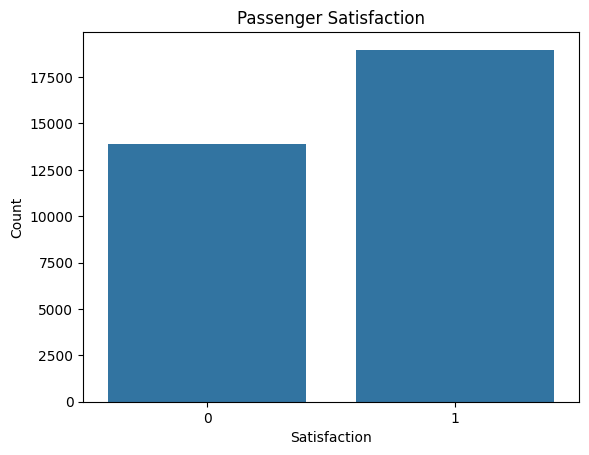

In [ ]:
sns.countplot(data=df, x="satisfaction")

plt.title("Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Count")

plt.show()

### **19. EDA: Numerical Column Distributions (Histograms)**

This cell iterates through all numerical columns in the DataFrame and generates a histogram for each. Histograms illustrate the distribution of values within a feature, helping to identify patterns, skewness, and the range of data. The `kde=True` argument adds a Kernel Density Estimate plot for a smoother representation of the distribution.

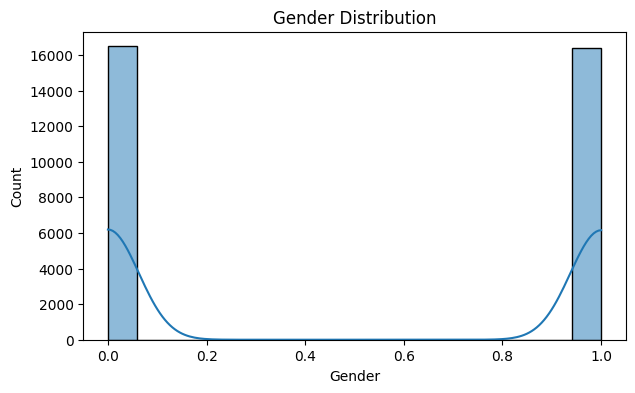

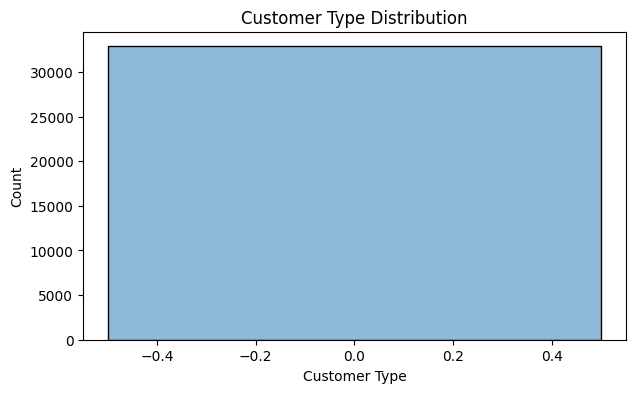

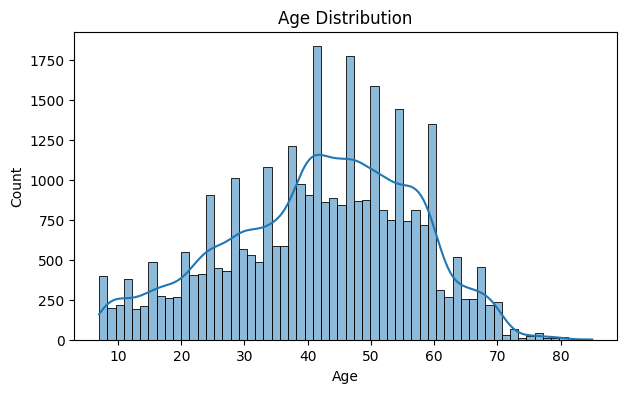

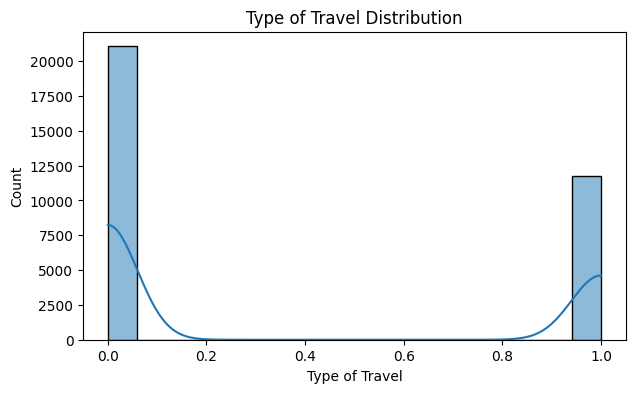

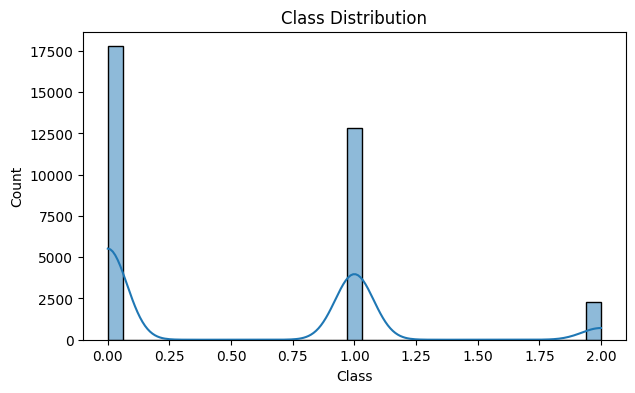

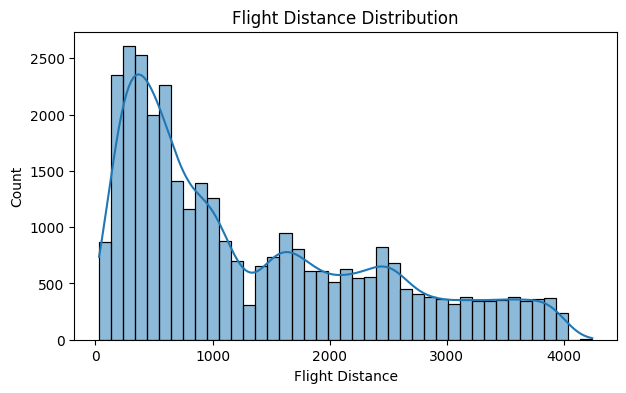

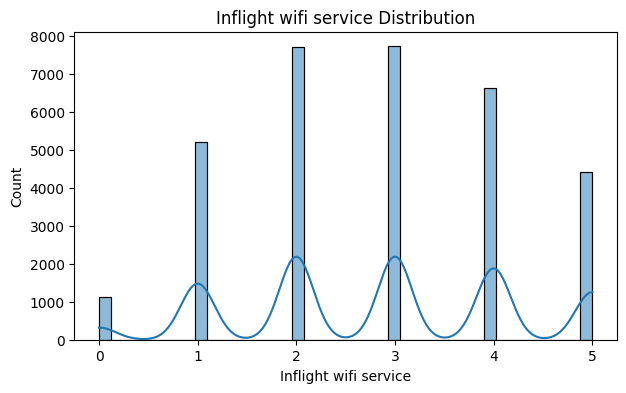

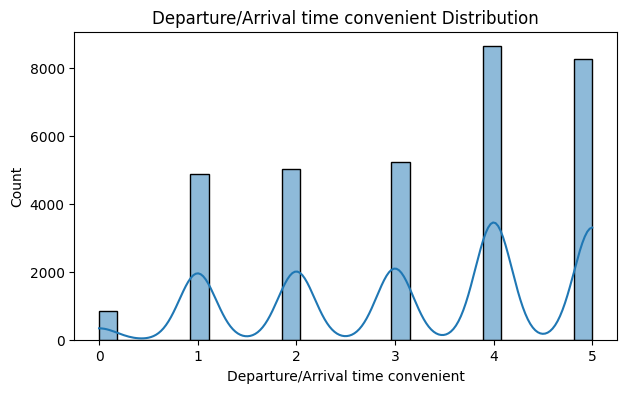

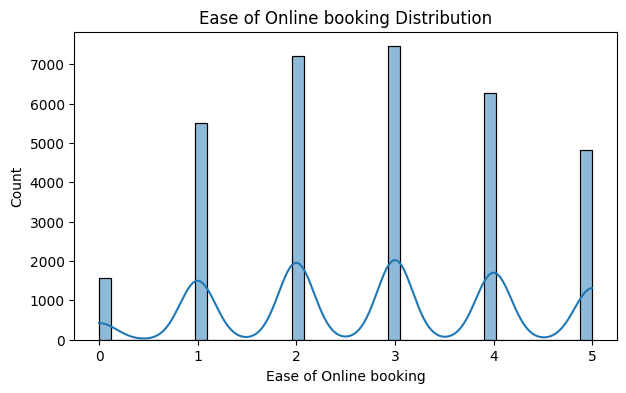

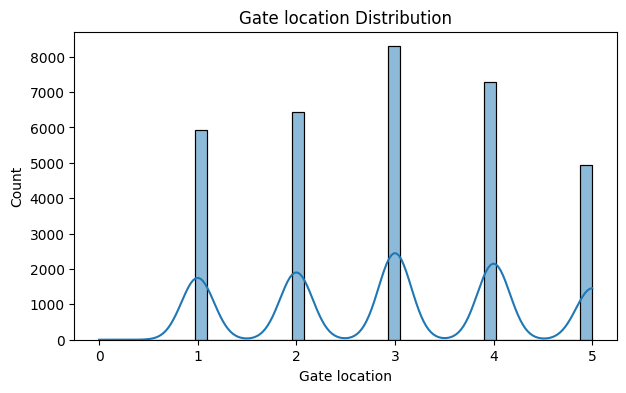

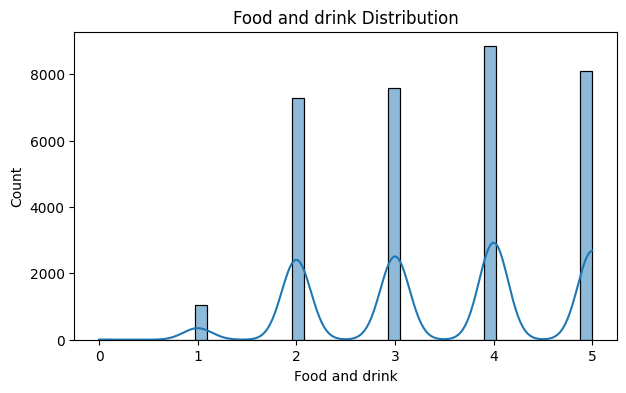

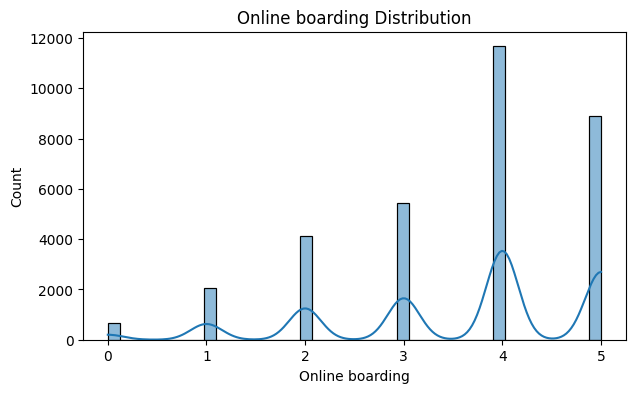

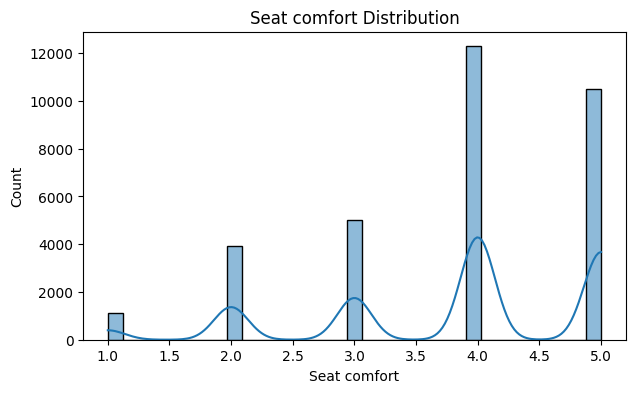

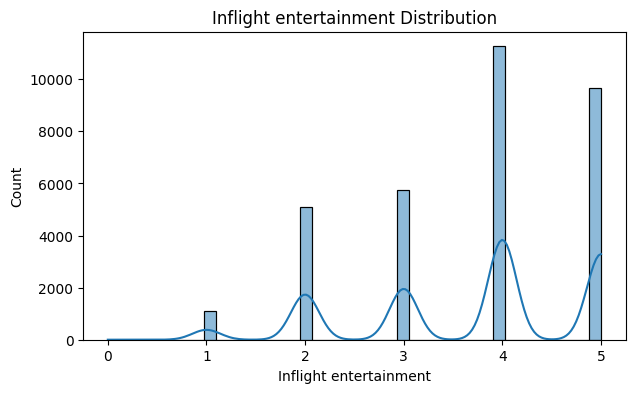

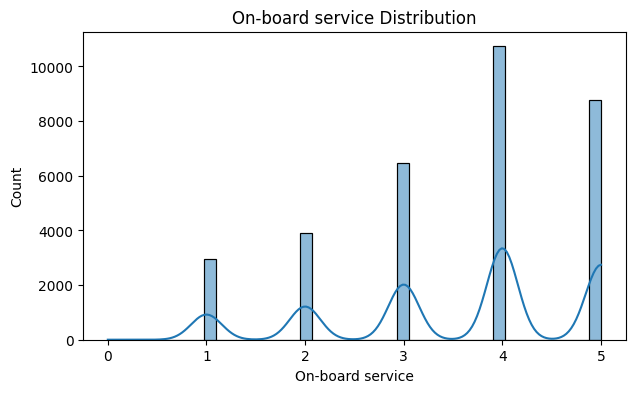

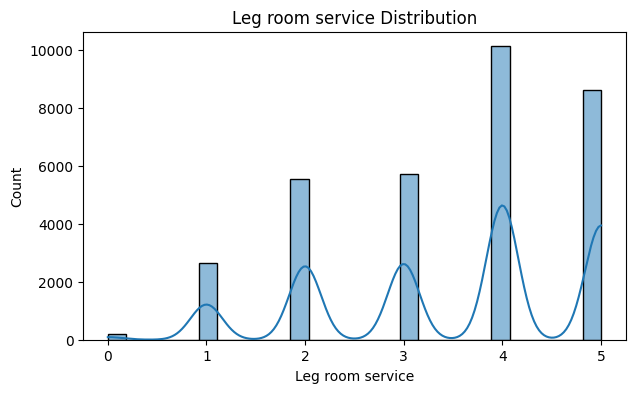

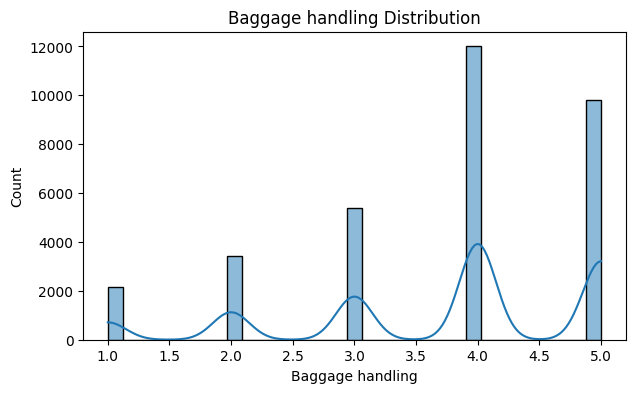

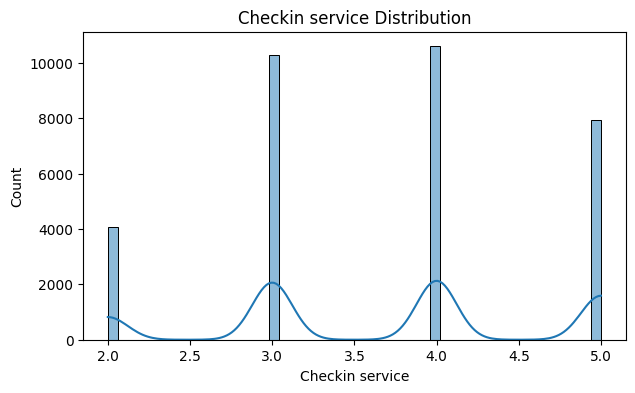

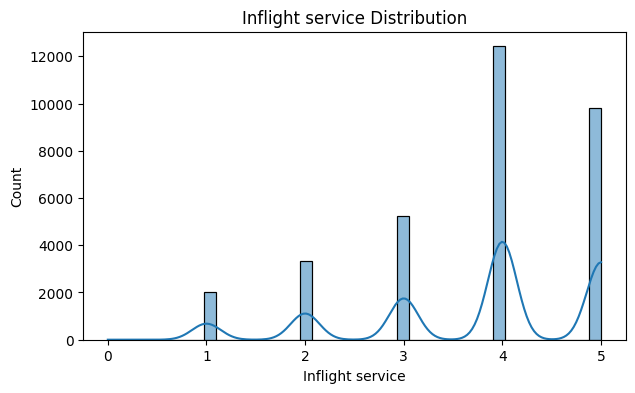

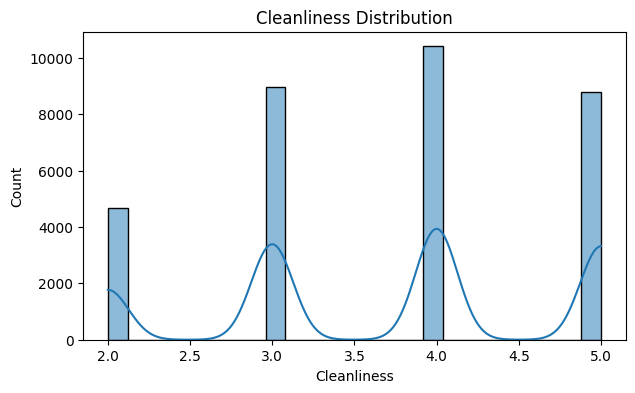

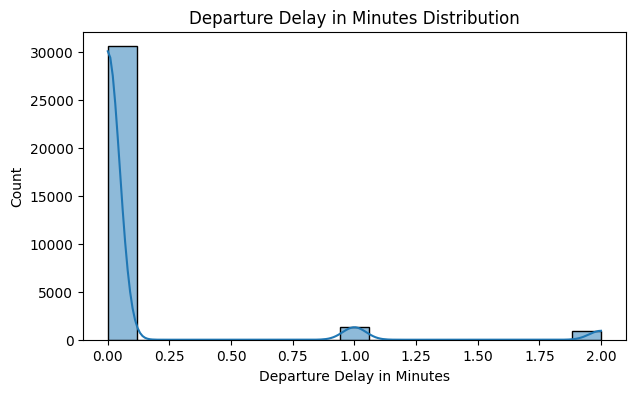

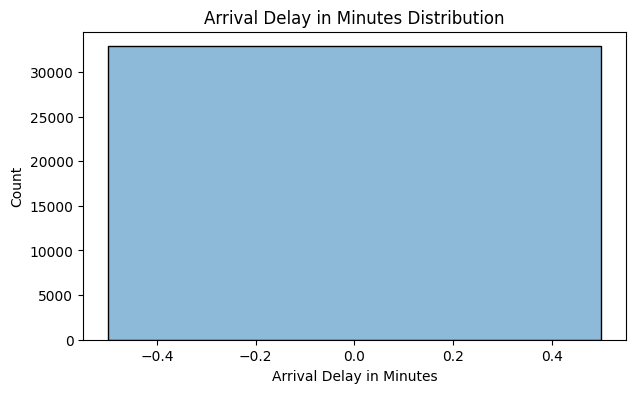

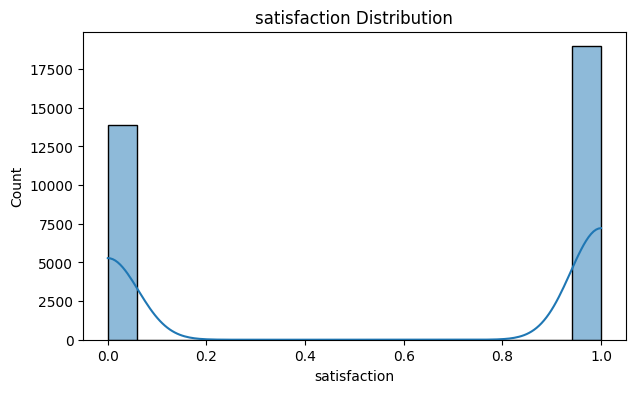

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

### **20. EDA: Numerical Column Distributions (Boxplots)**

This cell generates boxplots for all numerical columns. Boxplots are excellent for visualizing the central tendency, spread (interquartile range), and potential outliers for each numerical feature. They provide a quick summary of the data's distribution and highlight extreme values.

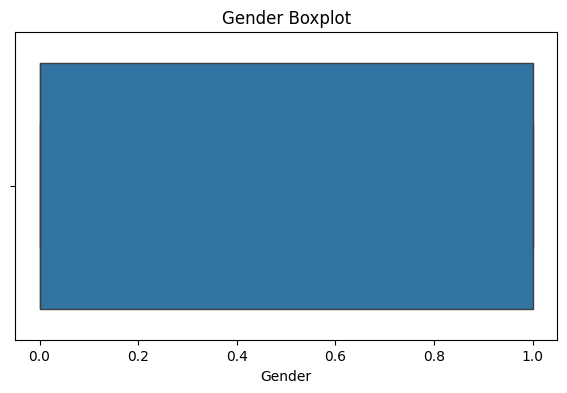

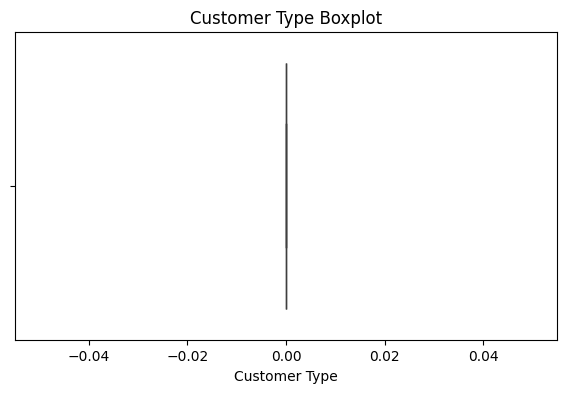

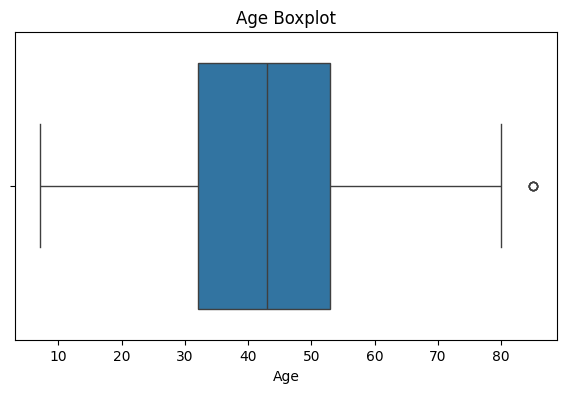

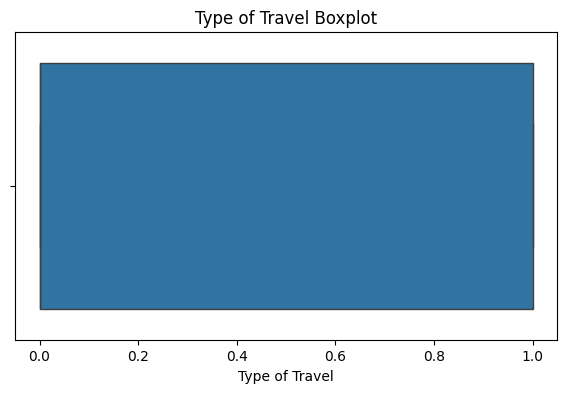

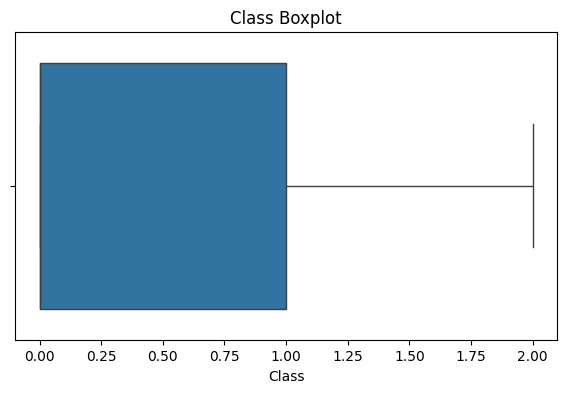

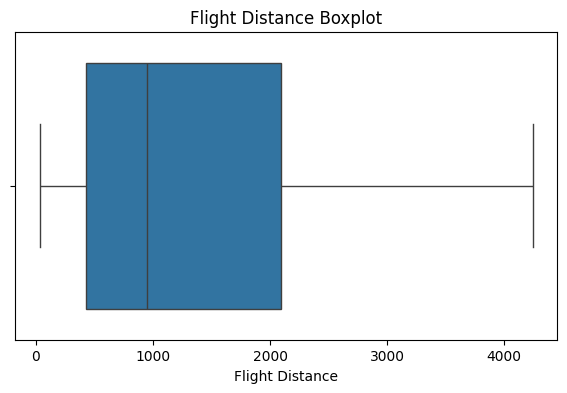

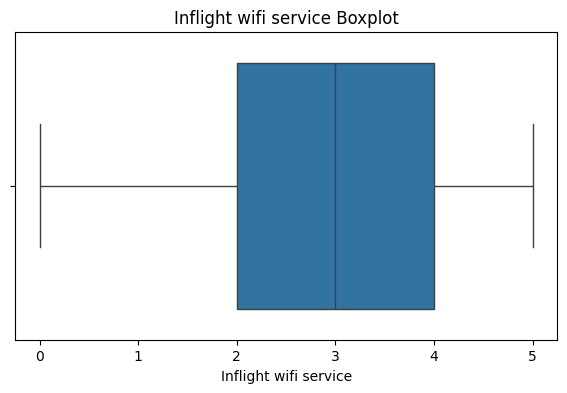

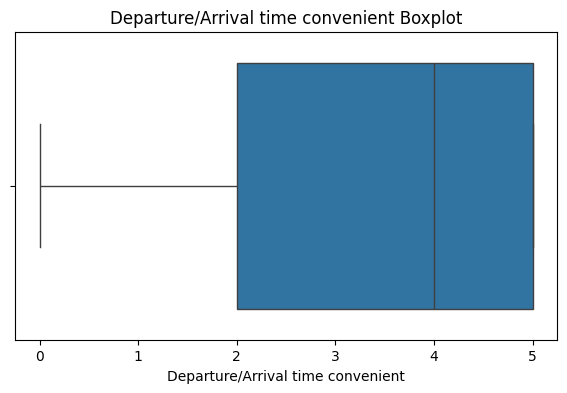

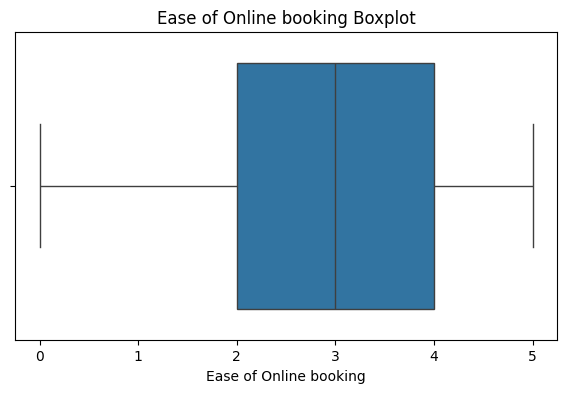

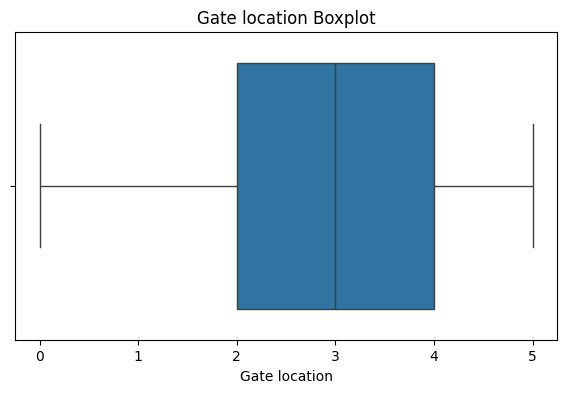

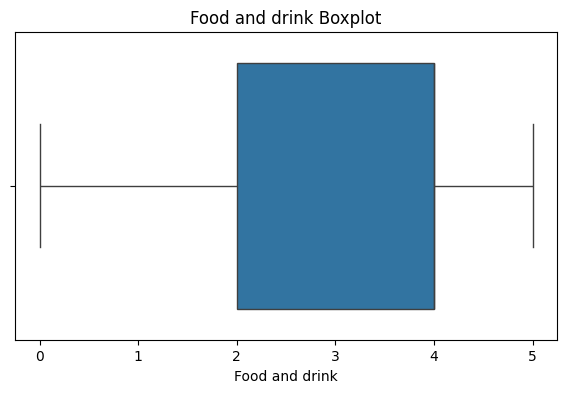

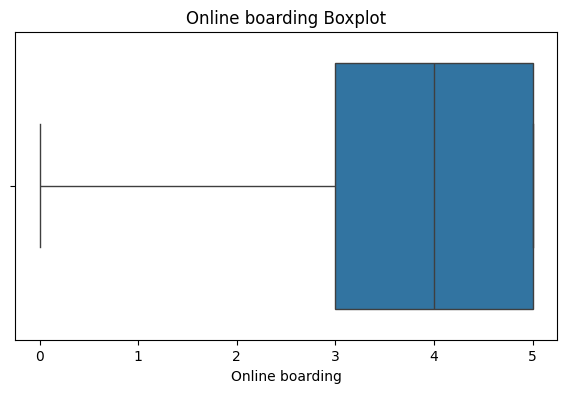

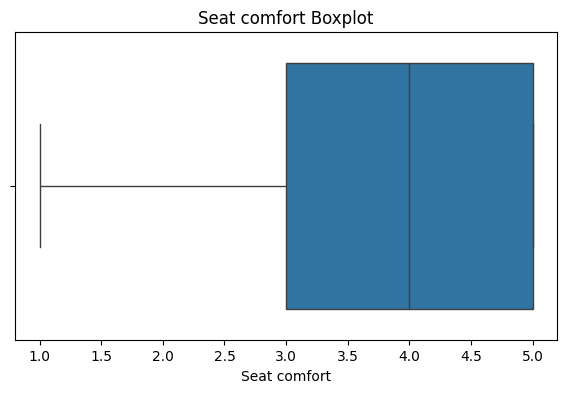

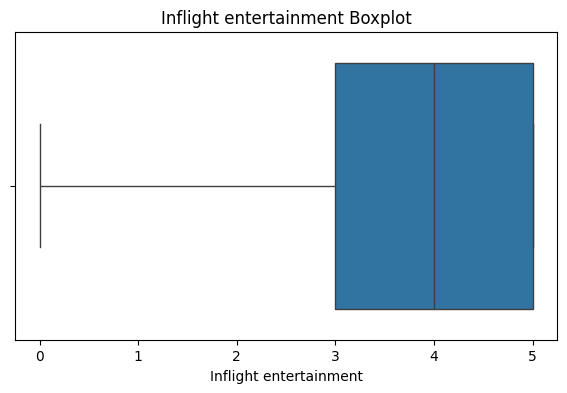

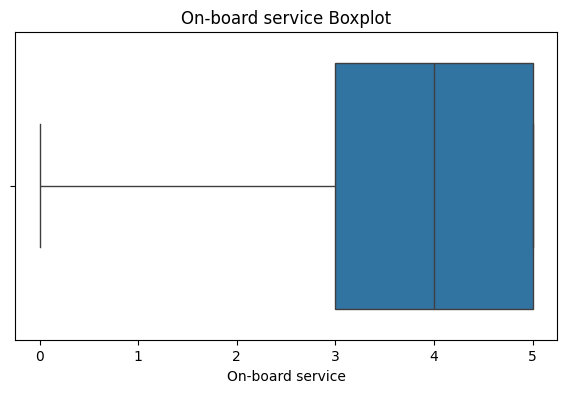

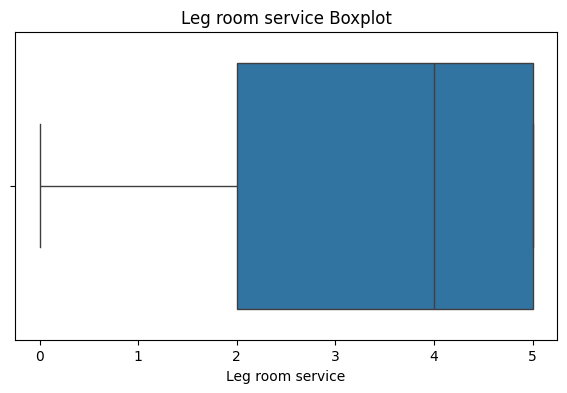

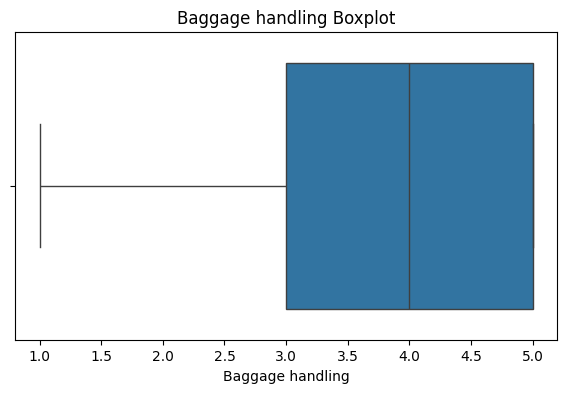

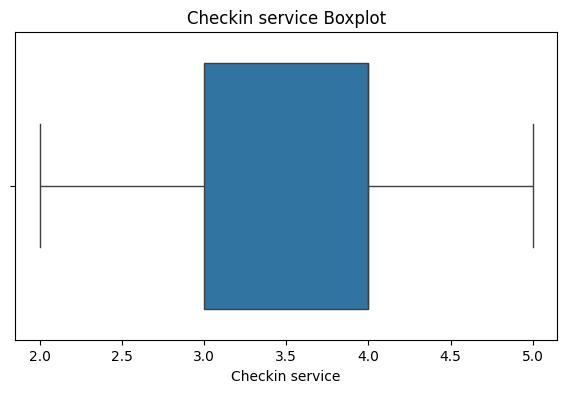

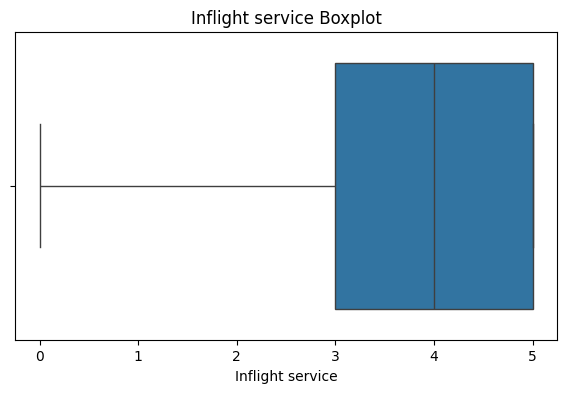

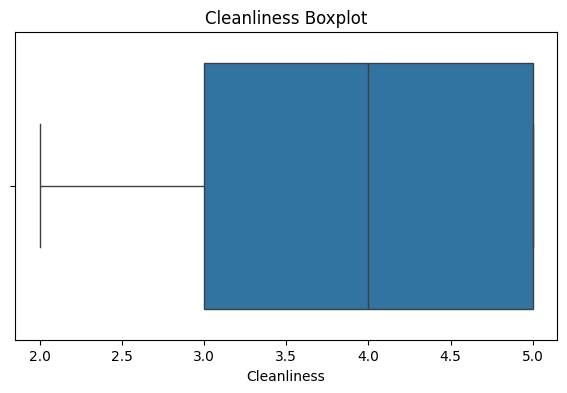

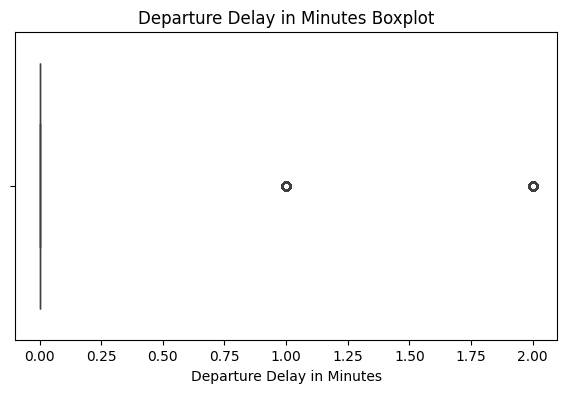

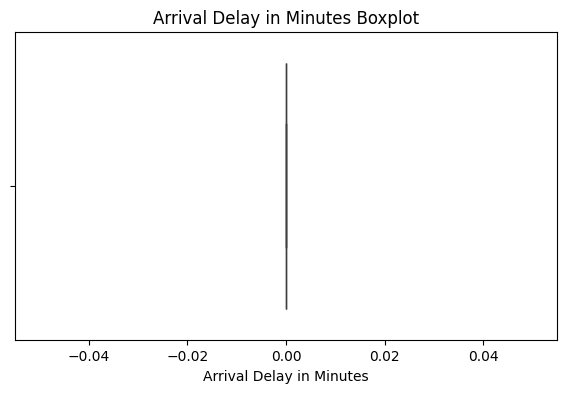

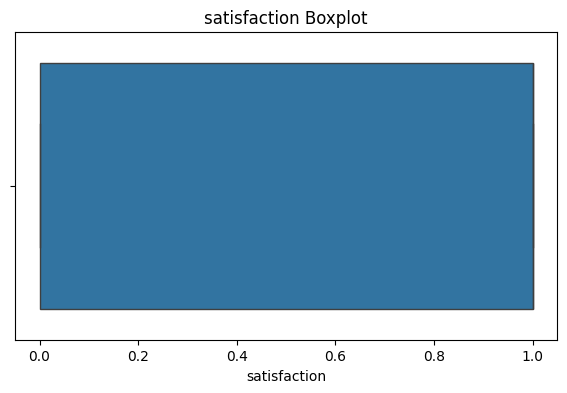

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

### **21. EDA: Categorical Column Distributions**

This cell iterates through all categorical (object type) columns and creates a countplot for each. Countplots show the frequency of each category within a feature, helping to understand their distribution and identify categories with very few instances.

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

### **22. EDA: Categorical Features vs. Satisfaction**

This cell explores the relationship between each categorical feature and the `satisfaction` target variable. It generates grouped countplots, showing the distribution of satisfied (1) and neutral/dissatisfied (0) passengers within each category of the other categorical features. This helps in identifying potential predictive features that strongly influence passenger satisfaction.

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    if col != "satisfaction":
        plt.figure(figsize=(8,5))

        sns.countplot(
            data=df,
            x=col,
            hue="satisfaction"
        )

        plt.title(f"{col} vs Satisfaction")
        plt.xticks(rotation=45)
        plt.show()

### **23. EDA: Correlation Matrix Calculation**

This cell calculates the pairwise correlation between all numerical columns in the DataFrame. The `corr()` method (with `numeric_only=True` to exclude non-numerical types) returns a correlation matrix, where each value indicates the strength and direction of the linear relationship between two features. Values range from -1 (perfect negative correlation) to 1 (perfect positive correlation).

In [ ]:
corr = df.corr(numeric_only=True)

corr

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
Gender,1.000000,NaN,-0.000144,-0.011657,0.000097,0.002835,0.017260,-0.000479,0.007069,0.009454,...,0.043355,0.003062,0.030614,0.043273,0.006746,0.046714,0.005430,0.008300,NaN,0.010479
Customer Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,-0.000144,NaN,1.000000,-0.155188,-0.117825,0.051962,0.000080,-0.036489,0.014628,-0.003010,...,-0.003916,0.056035,0.056183,-0.043048,0.037492,-0.042811,0.023600,-0.013583,NaN,0.118829
Type of Travel,-0.011657,NaN,-0.155188,1.000000,0.619473,-0.397474,-0.138051,0.261919,-0.142239,-0.041275,...,-0.219874,-0.140352,-0.237629,-0.070949,-0.012543,-0.060382,-0.117729,-0.004950,NaN,-0.679529
Class,0.000097,NaN,-0.117825,0.619473,1.000000,-0.474757,0.014354,0.163050,-0.081914,-0.022675,...,-0.188693,-0.230045,-0.258415,-0.170534,-0.099156,-0.159773,-0.125948,-0.018926,NaN,-0.533244
Flight Distance,0.002835,NaN,0.051962,-0.397474,-0.474757,1.000000,-0.000365,-0.102888,0.064700,0.014774,...,0.109414,0.130476,0.162053,0.098874,0.061745,0.089153,0.074510,0.019500,NaN,0.328498
Inflight wifi service,0.017260,NaN,0.000080,-0.138051,0.014354,-0.000365,1.000000,0.405025,0.732342,0.484489,...,0.193890,0.089501,0.162791,0.082890,0.001640,0.079289,0.106606,-0.009294,NaN,0.228655
Departure/Arrival time convenient,-0.000479,NaN,-0.036489,0.261919,0.163050,-0.102888,0.405025,1.000000,0.457091,0.556094,...,-0.050255,0.039582,-0.028409,0.059499,0.070598,0.063017,-0.013772,0.002247,NaN,-0.179913
Ease of Online booking,0.007069,NaN,0.014628,-0.142239,-0.081914,0.064700,0.732342,0.457091,1.000000,0.549454,...,0.061001,0.047226,0.138978,0.037343,-0.011278,0.036556,0.015829,-0.007567,NaN,0.142744
Gate location,0.009454,NaN,-0.003010,-0.041275,-0.022675,0.014774,0.484489,0.556094,0.549454,1.000000,...,0.007008,-0.010005,0.001658,0.005551,-0.022044,0.008153,-0.009446,-0.003864,NaN,0.022595


### **24. EDA: Correlation Heatmap Visualization**

This cell visualizes the calculated correlation matrix using a `heatmap` from `seaborn`. The `cmap="coolwarm"` color scheme helps in easily distinguishing positive (warm colors) and negative (cool colors) correlations, while `annot=True` displays the actual correlation values on the heatmap. This provides a clear graphical representation of feature interdependencies.

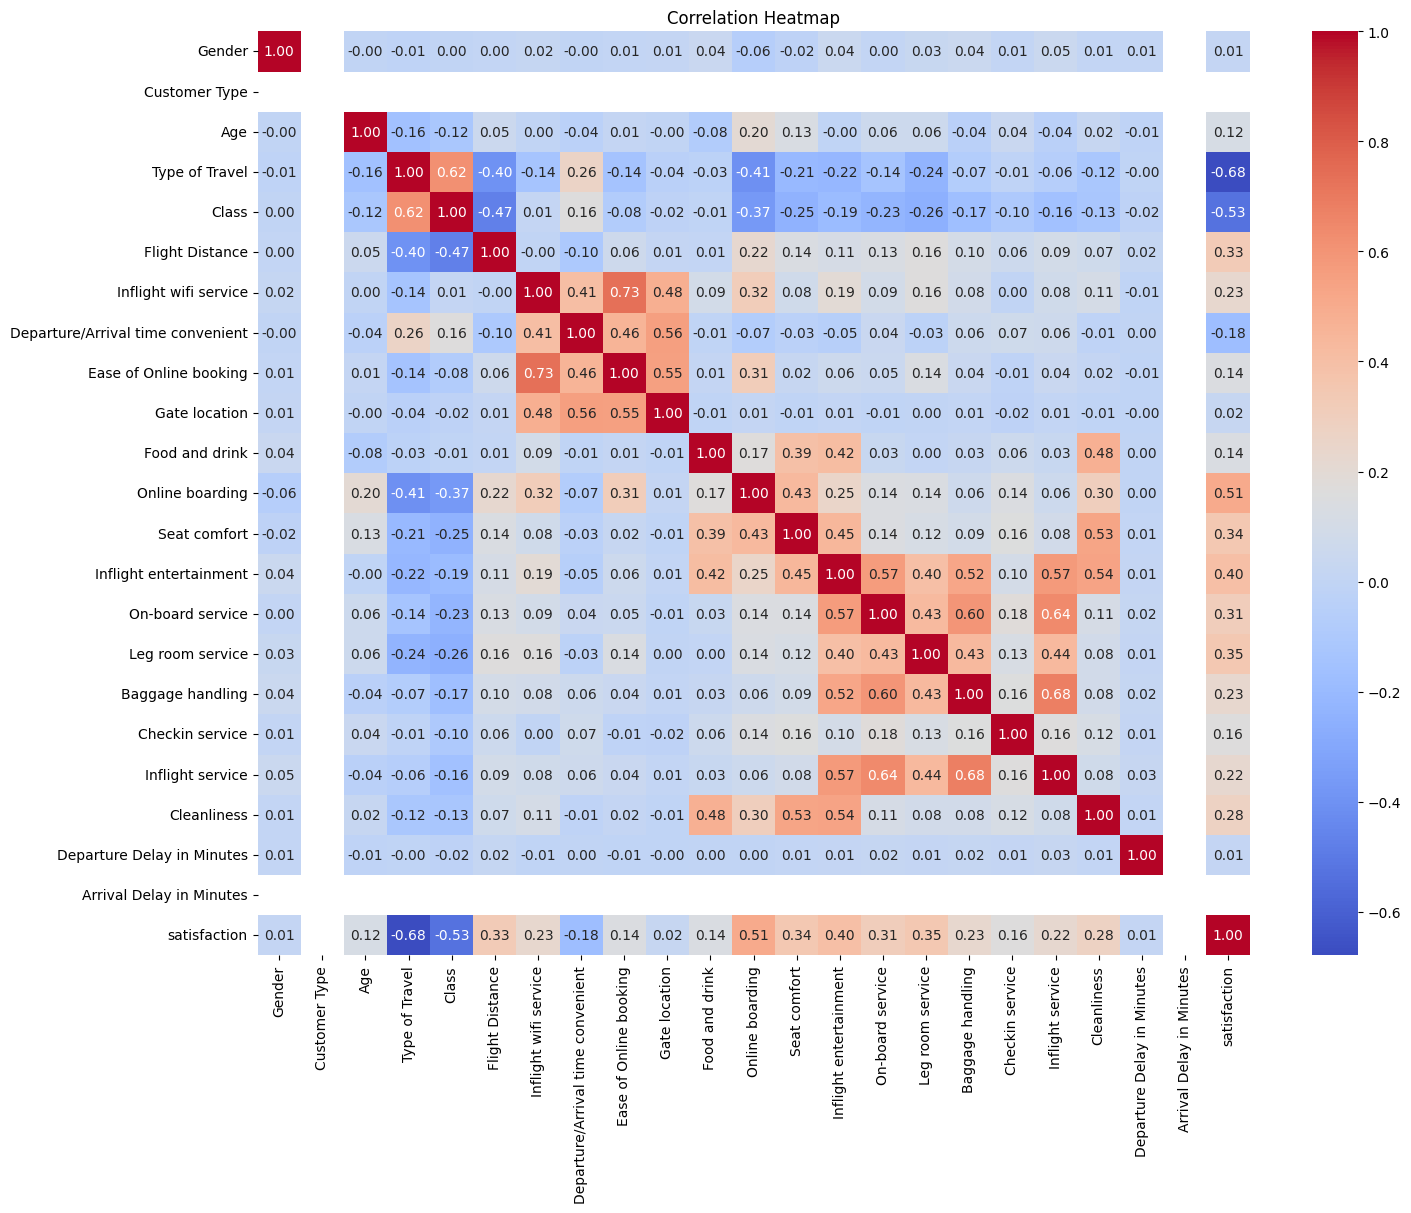

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### **25. Outlier Detection (Initial Scan)**

This cell performs an initial scan for outliers in each numerical column using the Interquartile Range (IQR) method. Outliers are defined as values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`. The cell prints the count of outliers found for each numerical feature, highlighting columns like 'Age' and 'Departure Delay in Minutes' with notable outlier counts.

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", len(outliers))

Gender : 0
Customer Type : 0
Age : 4
Type of Travel : 0
Class : 0
Flight Distance : 0
Inflight wifi service : 0
Departure/Arrival time convenient : 0
Ease of Online booking : 0
Gate location : 0
Food and drink : 0
Online boarding : 0
Seat comfort : 0
Inflight entertainment : 0
On-board service : 0
Leg room service : 0
Baggage handling : 0
Checkin service : 0
Inflight service : 0
Cleanliness : 0
Departure Delay in Minutes : 2269
Arrival Delay in Minutes : 0
satisfaction : 0


### **26. Outlier Removal (General)**

This cell iteratively removes rows containing outliers from the DataFrame for all numerical columns. For each numerical column, it calculates the IQR and filters the DataFrame, keeping only the rows where the values for that column are within the calculated `lower_limit` and `upper_limit`. This process reduces the dataset size but aims to improve model performance by removing extreme data points.

*Note: The shape `(30582, 23)` indicates a reduction from the initial `(103904, 25)` after previous steps and outlier removal.*

### **27. Outlier Removal Check (Boxplots Post-General Removal)**

This cell re-visualizes the numerical columns using boxplots after the general outlier removal step. The purpose is to observe the effect of outlier removal on the data distributions and confirm if the extreme values have been reduced or eliminated. While some data points outside the 'whiskers' might still be shown by seaborn, the overall spread should be less.

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (30582, 23)


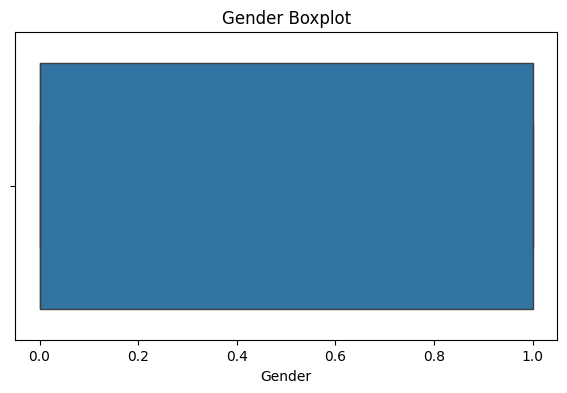

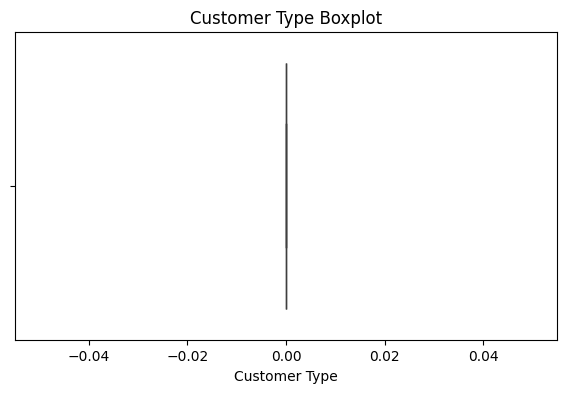

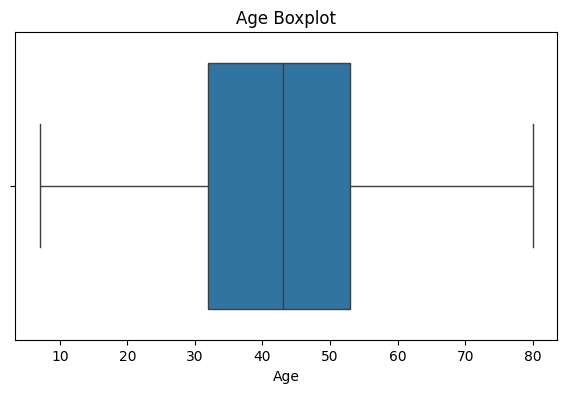

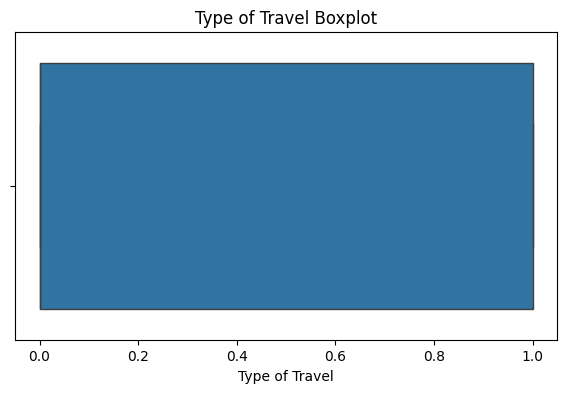

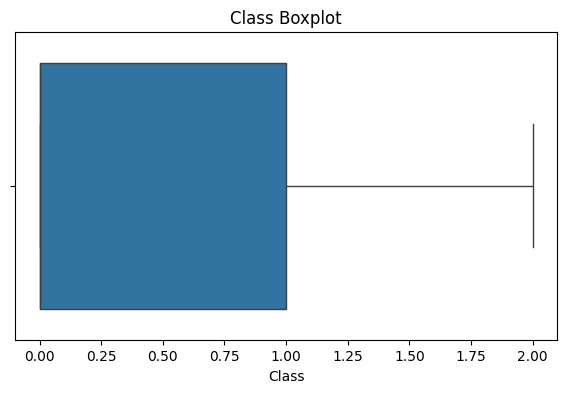

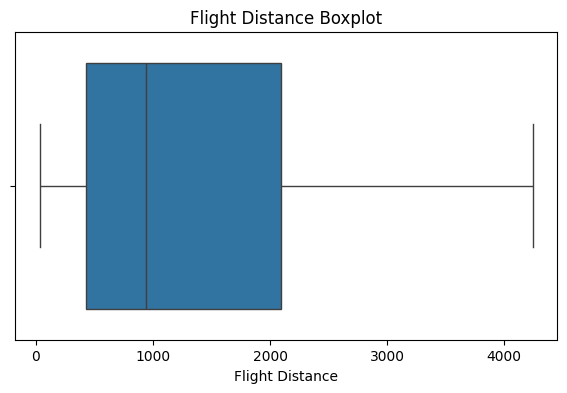

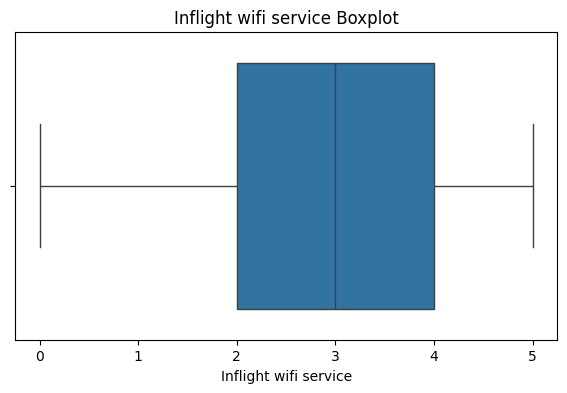

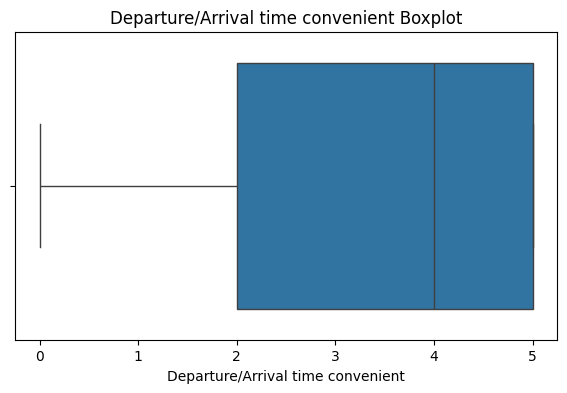

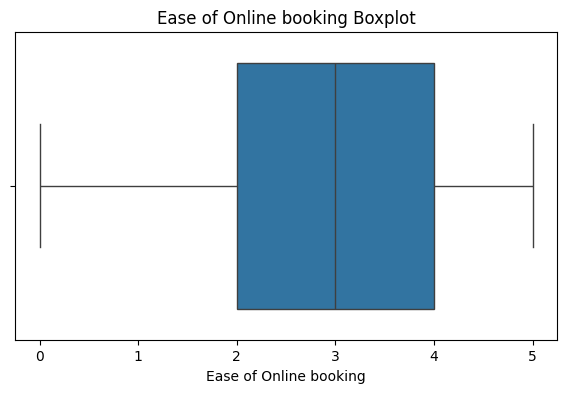

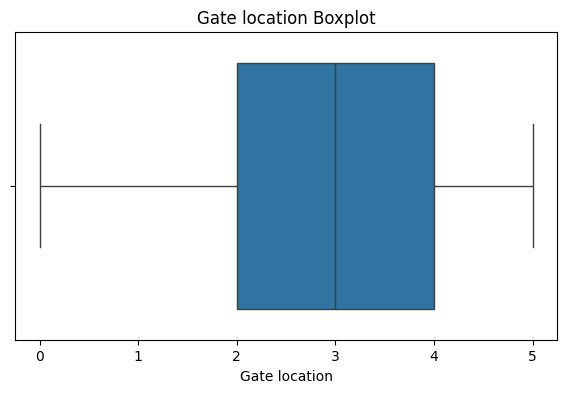

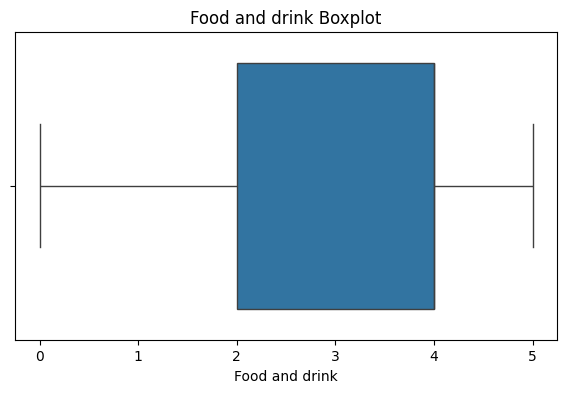

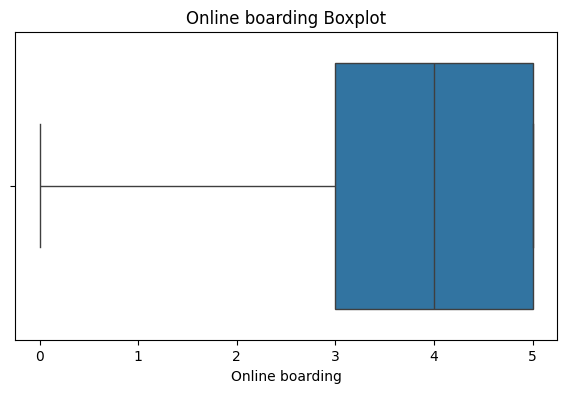

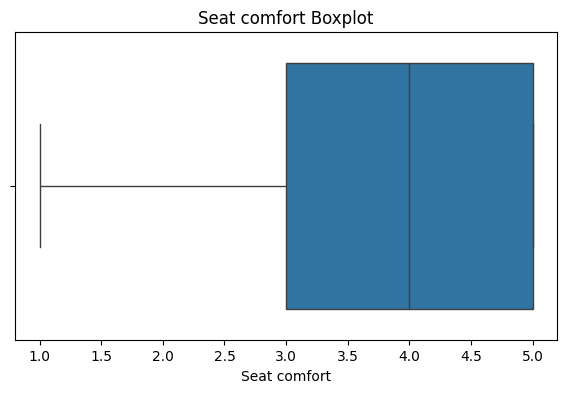

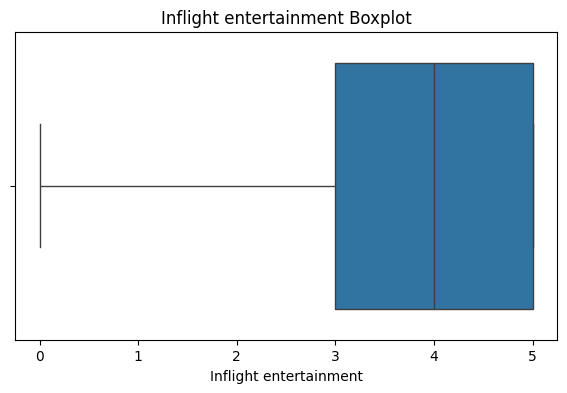

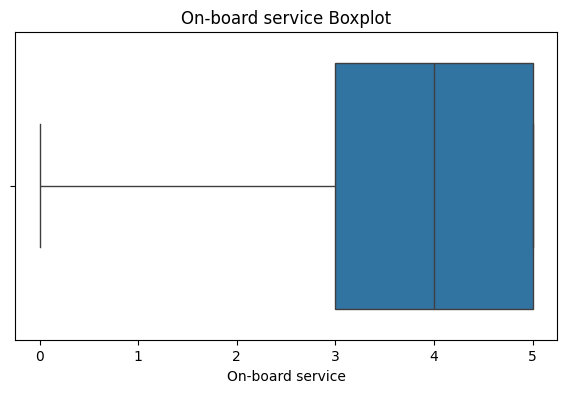

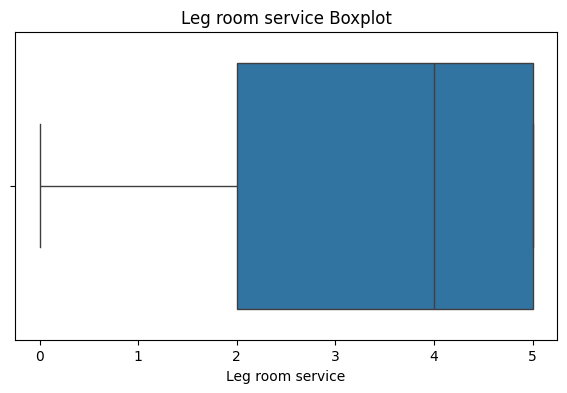

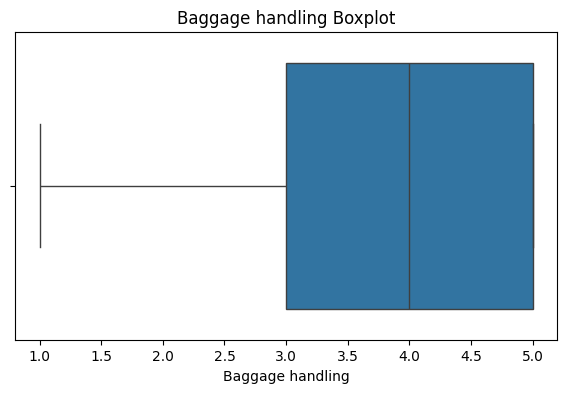

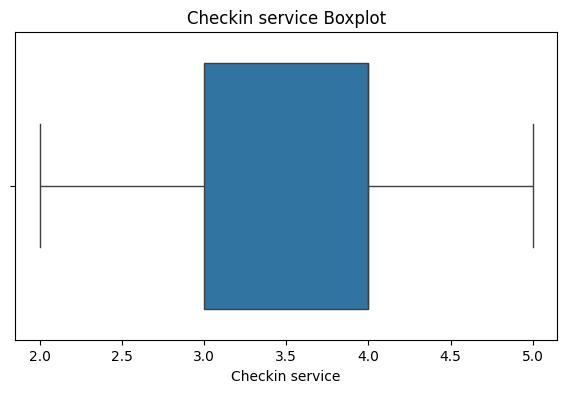

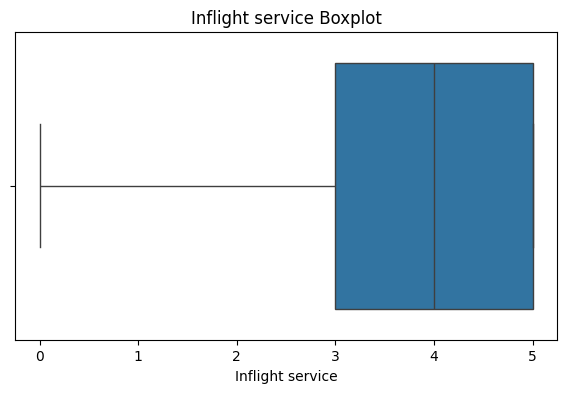

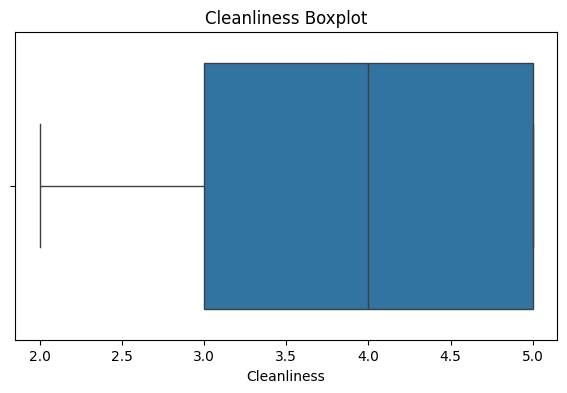

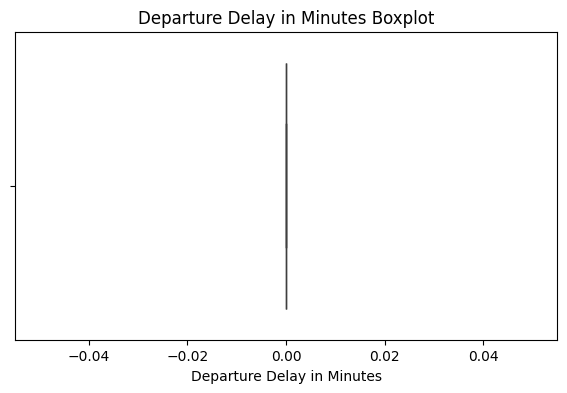

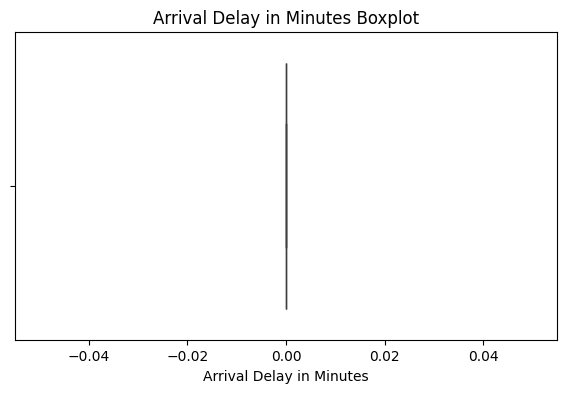

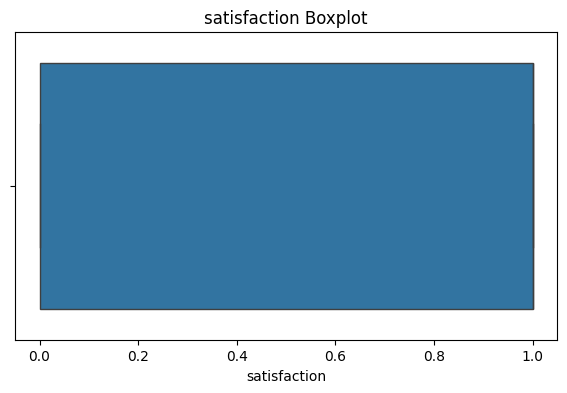

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

### **28. Outlier Removal (Specific for Delay Columns)**

This cell performs another round of outlier removal, specifically targeting 'Departure Delay in Minutes' and 'Arrival Delay in Minutes'. This might be done to ensure these critical features, which often contain many outliers, are thoroughly cleaned. The output confirms the DataFrame shape remains `(30582, 23)`, suggesting that either the previous general removal was already effective for these, or the definition of outliers did not lead to further removals.

In [ ]:
cols = [
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (30582, 23)


### **29. Outlier Removal Check (Boxplots Post-Specific Removal)**

This cell visualizes the 'Departure Delay in Minutes' and 'Arrival Delay in Minutes' columns using boxplots after the specific outlier removal step. This provides a visual confirmation that outliers in these particular delay-related features have been handled, ideally showing a more contained distribution without extreme values.

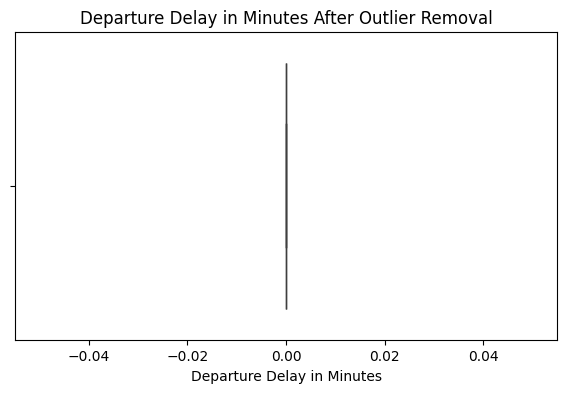

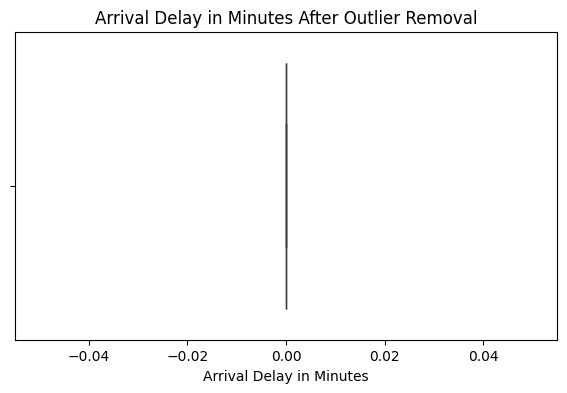

In [ ]:
for col in cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} After Outlier Removal")
    plt.show()

### **30. Data Splitting: Features (X) and Target (y)**

This cell separates the processed DataFrame into two main components: `X` (features) and `y` (target variable). `X` contains all columns except 'satisfaction', which are used to train the model, while `y` contains only the 'satisfaction' column, which the model aims to predict. This is a standard practice in supervised machine learning.

In [ ]:
X = df.drop("satisfaction", axis=1)

y = df["satisfaction"]

### **31. Data Splitting: Train-Test Split**

This cell divides the `X` and `y` datasets into training and testing sets using `train_test_split` from `sklearn.model_selection`.
*   `test_size=0.2` allocates 20% of the data for testing and 80% for training.
*   `random_state=42` ensures reproducibility of the split.
*   `stratify=y` ensures that the proportion of target classes is maintained in both training and testing sets, which is important for imbalanced datasets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **32. Data Split Shapes Verification**

This cell prints the shapes (number of rows and columns) of the `X_train`, `X_test`, `y_train`, and `y_test` datasets. This verifies that the `train_test_split` operation was successful and that the data is correctly partitioned into the expected dimensions.

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24465, 22)
X_test: (6117, 22)
y_train: (24465,)
y_test: (6117,)


### **33. Feature Scaling: Initial Standardization of Training Data**

This cell initializes a `StandardScaler` object from `sklearn.preprocessing`. It then applies `fit_transform` to `X_train`. This step calculates the mean and standard deviation of each feature in the training set and then scales the training data so that each feature has a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms that are sensitive to feature scales.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### **34. Feature Scaling: Redundant Standardization of Training Data**

This cell again applies `scaler.fit_transform(X_train)`. This is redundant as `X_train` was already `fit_transform`ed in the previous cell. While not harmful, it recalculates and reapplies the scaling parameters, which is unnecessary after the first `fit_transform`.

In [ ]:
scaler.fit_transform(X_train)

array([[ 1.0054512 ,  0.        ,  0.07297524, ..., -0.70054965,
         0.        ,  0.        ],
       [-0.99457836,  0.        , -0.19744876, ..., -0.70054965,
         0.        ,  0.        ],
       [ 1.0054512 ,  0.        , -1.00872075, ...,  1.2745523 ,
         0.        ,  0.        ],
       ...,
       [ 1.0054512 ,  0.        ,  0.68142924, ...,  1.2745523 ,
         0.        ,  0.        ],
       [-0.99457836,  0.        ,  1.69551923, ..., -0.70054965,
         0.        ,  0.        ],
       [-0.99457836,  0.        ,  0.34339924, ...,  0.28700133,
         0.        ,  0.        ]])

### **35. Feature Scaling: Standardization of Test Data**

This cell applies `scaler.transform(X_test)`. It's important to use only `transform` on the test set, not `fit_transform`. This uses the mean and standard deviation *learned from the training data* to scale the test data. This prevents data leakage from the test set into the training process, ensuring an unbiased evaluation of the model's performance on unseen data.

In [ ]:
scaler.transform(X_test)

array([[ 1.00034249,  0.        ,  0.81088691, ...,  1.27658905,
        -0.25636497,  0.        ],
       [-0.99965763,  0.        , -1.0797259 , ..., -1.68315014,
        -0.25636497,  0.        ],
       [-0.99965763,  0.        ,  1.01345256, ...,  0.29000932,
         2.34821199,  0.        ],
       ...,
       [-0.99965763,  0.        , -0.74211647, ..., -1.68315014,
        -0.25636497,  0.        ],
       [ 1.00034249,  0.        ,  0.81088691, ...,  1.27658905,
        -0.25636497,  0.        ],
       [ 1.00034249,  0.        , -0.47202893, ...,  0.29000932,
        -0.25636497,  0.        ]])

### **36. Model Training: Logistic Regression and Decision Tree**

This cell trains two distinct classification models:
*   **Logistic Regression (`model_lr`):** A linear model for binary classification. `max_iter=1000` sets the maximum iterations for convergence.
*   **Decision Tree Classifier (`model_dt`):** A non-linear, tree-based model. `max_depth=10` is set to limit the tree's depth, helping to prevent overfitting.

Both models are trained using the scaled training features (`X_train`) and target labels (`y_train`).

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

### **37. Model Training: Random Forest Classifier**

This cell trains a `RandomForestClassifier`. Random Forest is an ensemble learning method that builds multiple decision trees during training and outputs the mode of the classes for classification.
*   `n_estimators=200`: Creates 200 decision trees.
*   `max_depth=15`: Limits the depth of each tree.
*   `n_jobs=-1`: Utilizes all available CPU cores for faster training.
*   `random_state=42`: Ensures reproducibility.

This model is known for its robustness and ability to handle complex datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42)

### **38. Model Prediction on Test Data**

This cell uses the trained Logistic Regression, Decision Tree, and Random Forest models to make predictions on the unseen test set (`X_test`). The `predict()` method outputs the predicted class labels (0 or 1) for each instance in `X_test`. These predictions (`y_pred_lr`, `y_pred_dt`, `y_pred_rf`) will be used for evaluating the models.

In [ ]:
y_pred_lr = model_lr.predict(X_test)

y_pred_dt = model_dt.predict(X_test)

y_pred_rf = model_rf.predict(X_test)

### **39. Model Evaluation: Accuracy and Classification Reports (LR, DT, RF)**

This cell evaluates the performance of the Logistic Regression, Decision Tree, and Random Forest models using two key metrics:
*   **`accuracy_score`:** Calculates the proportion of correctly classified instances.
*   **`classification_report`:** Provides a detailed summary including precision, recall, and F1-score for each class (0 and 1), as well as overall accuracy. These metrics are crucial for understanding the strengths and weaknesses of each model.

The output shows Random Forest achieving the highest accuracy among these three.

In [ ]:

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      2776
           1       0.90      0.90      0.90      3795

    accuracy                           0.89      6571
   macro avg       0.89      0.88      0.88      6571
weighted avg       0.89      0.89      0.89      6571

Logistic Regression Accuracy: 0.8876883274996196
Decision Tree Accuracy: 95.51057677674632

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2776
           1       0.96      0.96      0.96      3795

    accuracy                           0.96      6571
   macro avg       0.95      0.95      0.95      6571
weighted avg       0.96      0.96      0.96      6571

Random Forest Accuracy: 95.95190990716786 %

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2776
           1       0.97      0.96      0.96      3795


### **40. Model Evaluation: Classification Report (Logistic Regression)**

This cell specifically prints the `classification_report` for the Logistic Regression model. This is redundant as the report for Logistic Regression was already printed in the previous cell alongside the others. However, it isolates the output for this specific model, which might be for clarity or specific analysis.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      2776
           1       0.90      0.90      0.90      3795

    accuracy                           0.89      6571
   macro avg       0.89      0.88      0.88      6571
weighted avg       0.89      0.89      0.89      6571



### **41. Model Comparison: Results DataFrame**

This cell creates a pandas DataFrame named `results` to consolidate the accuracy scores of the Logistic Regression, Decision Tree, and Random Forest models. Presenting the results in a DataFrame makes it easy to compare the models' performances side-by-side in a structured table.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.887688
1,Decision Tree,0.955106
2,Random Forest,0.959519


### **42. Model Comparison: Accuracy Bar Plot**

This cell visualizes the accuracy comparison of the three models (Logistic Regression, Decision Tree, Random Forest) using a `barplot` from `seaborn`. This provides a clear and intuitive graphical representation, making it easy to quickly identify which model achieved the highest accuracy.

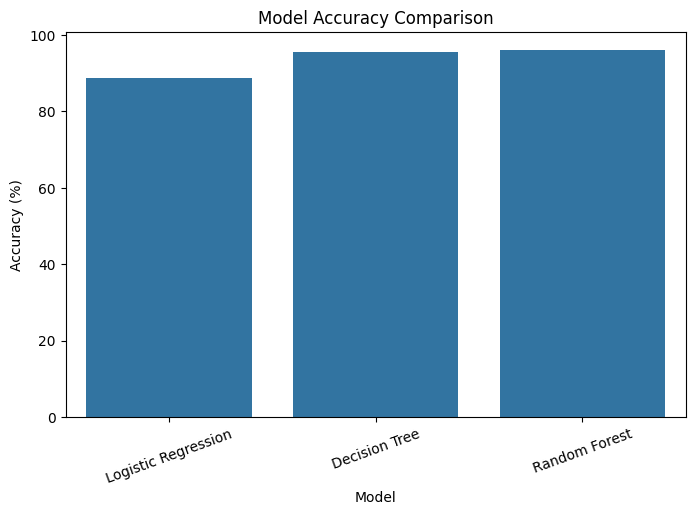

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.show()

### **43. Model Training and Evaluation: XGBoost Classifier**

This cell introduces and evaluates an **XGBoost Classifier**, an advanced gradient boosting algorithm known for its high performance.

1.  **Model Creation:** An `XGBClassifier` is initialized with optimized hyperparameters like `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`.
2.  **Training:** The model is trained on `X_train` and `y_train`.
3.  **Prediction:** Predictions (`y_pred_xgb`) and prediction probabilities (`y_prob_xgb`) are generated for the test set.
4.  **Evaluation:** It calculates and prints `accuracy_score`, `classification_report`, `roc_auc_score`, and `confusion_matrix`. The output shows XGBoost achieves the highest accuracy among all models, along with an excellent ROC-AUC score and a clear confusion matrix.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# 2. Train Model
xgb_model.fit(X_train, y_train)


# 3. Prediction
y_pred_xgb = xgb_model.predict(X_test)


# 4. Prediction Probability
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# 5. Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost Accuracy:", accuracy_xgb * 100, "%")


# 6. Classification Report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_xgb))


# 7. ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC Score:", roc_auc_xgb)


# 8. Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\n===== CONFUSION MATRIX =====")
print(cm_xgb)




XGBoost Accuracy: 0.9625627758332065
XGBoost Accuracy: 96.25627758332065 %

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2776
           1       0.98      0.96      0.97      3795

    accuracy                           0.96      6571
   macro avg       0.96      0.96      0.96      6571
weighted avg       0.96      0.96      0.96      6571

ROC-AUC Score: 0.9954796049708967

===== CONFUSION MATRIX =====
[[2685   91]
 [ 155 3640]]


### **44. Model Evaluation: ROC Curve for XGBoost**

This cell plots the Receiver Operating Characteristic (ROC) curve for the trained XGBoost model. The ROC curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR). The area under the curve (AUC), previously calculated as `roc_auc_xgb`, quantifies the overall performance, with a higher AUC indicating a better model.

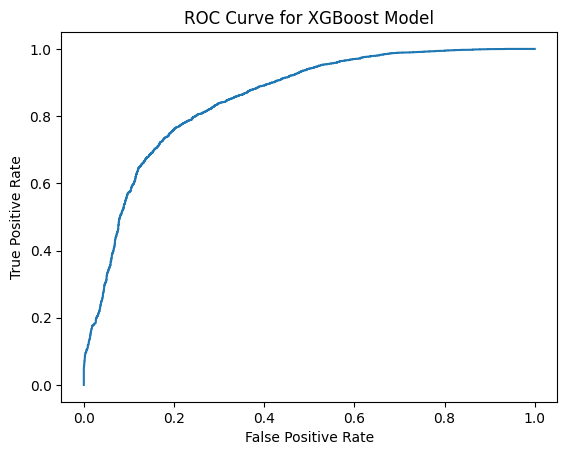

In [ ]:
from sklearn.metrics import roc_curve

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1] # Re-calculate y_prob_xgb to match current X_test
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Model')
plt.show()

### **45. Model Saving: Define Filename**

This cell defines the filename `ml_model.joblib` that will be used to save the trained machine learning model. Using `joblib` is a common practice for serializing Python objects, including scikit-learn models, allowing them to be stored and reloaded later.

In [ ]:
import joblib

# 1. Dump (Save) the model to a file
model_filename = "ml_model.joblib"


### **46. Model Saving: Execute Save**

This cell uses `joblib.dump()` to save the best-performing model (`xgb_model`) to the specified `model_filename`. This process serializes the model object into a binary file, enabling its persistent storage. The output confirms that the model has been successfully saved, making it available for future use without needing to retrain it.

In [ ]:
joblib.dump(xgb_model, model_filename)
print(f"Model successfully saved to {model_filename}")


Model successfully saved to ml_model.joblib


### **47. Model Loading (Demonstration)**

This cell demonstrates how to load a previously saved machine learning model. It uses `joblib.load()` to deserialize the `ml_model.joblib` file back into a Python object, which is assigned to `loaded_model`. This `loaded_model` can then be used to make new predictions on fresh data without the need for retraining, showcasing a typical deployment scenario.

In [ ]:
loaded_model = joblib.load(model_filename)
# predictions = loaded_model.predict(X_test)
